<h3 style="color:#ef5A85;font-weight:600;">1 | Nested Pie Charts (donut charts) - `pie` method</h3>

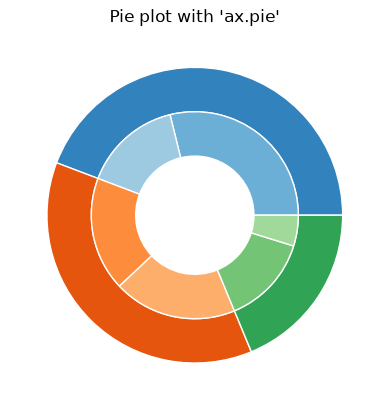

In [1]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

size = 0.3
vals = np.array(
    [
        [60.0, 32.0],
        [37.0, 40.0],
        [29.0, 10.0],
    ]
)

tab20c = plt.color_sequences["tab20c"]
outer_colors = [tab20c[i] for i in [0, 4, 8]]
inner_colors = [tab20c[i] for i in [1, 2, 5, 6, 9, 10]]

ax.pie(
    vals.sum(axis=1),
    radius=1,
    colors=outer_colors,
    wedgeprops=dict(width=size, edgecolor="w"),
)

ax.pie(
    vals.flatten(),
    radius=1 - size,
    colors=inner_colors,
    wedgeprops=dict(width=size, edgecolor="w"),
)

ax.set(aspect="equal", title="Pie plot with 'ax.pie'")
plt.show()

<h3 style="color:#ef5A85;font-weight:600;">2 | Nested Pie Charts (donut charts) - `bar` method & polar coordinates</h3>

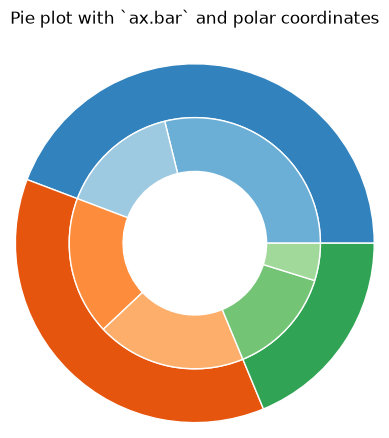

In [14]:
fig, ax = plt.subplots(subplot_kw=dict(projection="polar"))

size = 0.3
vals = np.array(
    [
        [60.0, 32.0],
        [37.0, 40.0],
        [29.0, 10.0],
    ]
)

# Normalize values to 2π
valsnorm = vals / np.sum(vals) * 2 * np.pi

# Obtain the ordinates of the bar edges
valsleft = np.cumsum(np.append(0, valsnorm.flatten()[:-1])).reshape(vals.shape)

cmap = plt.colormaps["tab20c"]
outer_colors = cmap(np.arange(3) * 4)
inner_colors = cmap([1, 2, 5, 6, 9, 10])

ax.bar(
    x=valsleft[:, 0],
    width=valsnorm.sum(axis=1),
    bottom=1 - size,
    height=size,
    color=outer_colors,
    edgecolor="w",
    linewidth=1,
    align="edge",
)

ax.bar(
    x=valsleft.flatten(),
    width=valsnorm.flatten(),
    bottom=1 - 2 * size,
    height=size,
    color=inner_colors,
    edgecolor="w",
    linewidth=1,
    align="edge",
)

ax.set(title="Pie plot with `ax.bar` and polar coordinates")
ax.set_axis_off()
plt.show()